# Nightly Report: IQ, AOS, Thermal, Aberrations and Degrees of Freedom

Owner: **Guillem Megias** <br>
Last Verified to Run: **2025-07-07** <br>

In [1]:
# Times Square Parameters
day_obs = 20250706
seq_min = 100
seq_max = 200

In [2]:
import galsim
import numpy as np

def getPsfGradPerZernike(
    diameter: float = 8.36,
    obscuration: float = 0.612,
    jmin: int = 4,
    jmax: int = 22,
) -> np.ndarray:
    """Get the gradient of the PSF FWHM with respect to each Zernike.

    This function takes no positional arguments. All parameters must be passed
    by name (see the list of parameters below).

    Parameters
    ----------
    diameter : float, optional
        The diameter of the telescope aperture, in meters.
        (the default, 8.36, corresponds to the LSST primary mirror)
    obscuration : float, optional
        Central obscuration of telescope aperture (i.e. R_outer / R_inner).
        (the default, 0.612, corresponds to the LSST primary mirror)
    jmin : int, optional
        The minimum Noll index, inclusive. Must be >= 0. (the default is 4)
    jmax : int, optional
        The max Zernike Noll index, inclusive. Must be >= jmin.
        (the default is 22.)

    Returns
    -------
    np.ndarray
        Gradient of the PSF FWHM with respect to the corresponding Zernike.
        Units are arcsec / micron.

    Raises
    ------
    ValueError
        If jmin is negative or jmax is less than jmin
    """
    # Check jmin and jmax
    if jmin < 0:
        raise ValueError("jmin cannot be negative.")
    if jmax < jmin:
        raise ValueError("jmax must be greater than jmin.")

    # Calculate the conversion factors
    conversion_factors = np.zeros(jmax + 1)
    for i in range(jmin, jmax + 1):
        # Set coefficients for this Noll index: coefs = [0, 0, ..., 1]
        # Note the first coefficient is Noll index 0, which does not exist and
        # is therefore always ignored by galsim
        coefs = [0] * i + [1]

        # Create the Zernike polynomial with these coefficients
        R_outer = diameter / 2
        R_inner = R_outer * obscuration
        Z = galsim.zernike.Zernike(coefs, R_outer=R_outer, R_inner=R_inner)

        # We can calculate the size of the PSF from the RMS of the gradient of
        # the wavefront. The gradient of the wavefront perturbs photon paths.
        # The RMS quantifies the size of the collective perturbation.
        # If we expand the wavefront gradient in another series of Zernike
        # polynomials, we can exploit the orthonormality of the Zernikes to
        # calculate the RMS from the Zernike coefficients.
        rms_tilt = np.sqrt(np.sum(Z.gradX.coef**2 + Z.gradY.coef**2) / 2)

        # Convert to arcsec per micron
        rms_tilt = np.rad2deg(rms_tilt * 1e-6) * 3600

        # Convert rms -> fwhm
        fwhm_tilt = 2 * np.sqrt(2 * np.log(2)) * rms_tilt

        # Save this conversion factor
        conversion_factors[i] = fwhm_tilt

    return conversion_factors[jmin:]


def convertZernikesToPsfWidth(
    zernikes: np.ndarray,
    diameter: float = 8.36,
    obscuration: float = 0.612,
    jmin: int = 4,
) -> np.ndarray:
    """Convert Zernike amplitudes to quadrature contribution to the PSF FWHM.

    Parameters
    ----------
    zernikes : np.ndarray
        Zernike amplitudes (in microns), starting with Noll index `jmin`.
        Either a 1D array of zernike amplitudes, or a 2D array, where each row
        corresponds to a different set of amplitudes.
    diameter : float
        The diameter of the telescope aperture, in meters.
        (the default, 8.36, corresponds to the LSST primary mirror)
    obscuration : float
        Central obscuration of telescope aperture (i.e. R_outer / R_inner).
        (the default, 0.612, corresponds to the LSST primary mirror)
    jmin : int
        The minimum Zernike Noll index, inclusive. Must be >= 0. The
        max Noll index is inferred from `jmin` and the length of `zernikes`.
        (the default is 4, which ignores piston, x & y offsets, and tilt.)

    Returns
    -------
    dFWHM: np.ndarray
        Quadrature contribution of each Zernike vector to the PSF FWHM
        (in arcseconds).

    Notes
    -----
    Converting Zernike amplitudes to their quadrature contributions to the PSF
    FWHM allows for easier physical interpretation of Zernike amplitudes and
    the performance of the AOS system.

    For example, image we have a true set of zernikes, [Z4, Z5, Z6], such that
    ConvertZernikesToPsfWidth([Z4, Z5, Z6]) = [0.1, -0.2, 0.3] arcsecs.
    These Zernike perturbations increase the PSF FWHM by
    sqrt[(0.1)^2 + (-0.2)^2 + (0.3)^2] ~ 0.37 arcsecs.

    If the AOS perfectly corrects for these perturbations, the PSF FWHM will
    not increase in size. However, imagine the AOS estimates zernikes, such
    that ConvertZernikesToPsfWidth([Z4, Z5, Z6]) = [0.1, -0.3, 0.4] arcsecs.
    These estimated Zernikes, do not exactly match the true Zernikes above.
    Therefore, the post-correction PSF will still be degraded with respect to
    the optimal PSF. In particular, the PSF FWHM will be increased by
    sqrt[(0.1 - 0.1)^2 + (-0.2 - (-0.3))^2 + (0.3 - 0.4)^2] ~ 0.14 arcsecs.

    This conversion depends on a linear approximation that begins to break down
    for RSS(dFWHM) > 0.20 arcsecs. Beyond this point, the approximation tends
    to overestimate the PSF degradation. In other words, if
    sqrt(sum( dFWHM^2 )) > 0.20 arcsec, it is likely that dFWHM is
    over-estimated. However, the point beyond which this breakdown begins
    (and whether the approximation over- or under-estimates dFWHM) can change,
    depending on which Zernikes have large amplitudes. In general, if you have
    large Zernike amplitudes, proceed with caution!
    Note that if the amplitudes Z_est and Z_true are large, this is okay, as
    long as |Z_est - Z_true| is small.

    For a notebook demonstrating where the approximation breaks down:
    https://gist.github.com/jfcrenshaw/24056516cfa3ce0237e39507674a43e1

    Raises
    ------
    ValueError
        If jmin is negative
    """
    # Check jmin
    if jmin < 0:
        raise ValueError("jmin cannot be negative.")

    # Calculate jmax from jmin and the length of the zernike array
    jmax = jmin + np.array(zernikes).shape[-1] - 1

    # Calculate the conversion factors for each zernike
    conversion_factors = getPsfGradPerZernike(
        jmin=jmin,
        jmax=jmax,
        diameter=diameter,
        obscuration=obscuration,
    )

    # Convert the Zernike amplitudes from microns to their quadrature
    # contribution to the PSF FWHM
    dFWHM = conversion_factors * zernikes

    return dFWHM

In [3]:
import logging

import pandas as pd
from astropy.time import Time, TimeDelta
from lsst.obs.lsst import LsstCam
from lsst.summit.utils import (
    ConsDbClient,
    getAirmassSeeingCorrection,
    getBandpassSeeingCorrection,
)
from lsst.summit.utils.efdUtils import (
    getEfdData,
    getMostRecentRowWithDataBefore,
    makeEfdClient,
)

from tqdm import tqdm as tqdm

__all__ = ["AOSDatabase"]


class AOSDatabase:
    table: pd.DataFrame

    def __init__(
        self,
        day_obs: int = 20250415,
        seq_min: int = 1,
        seq_max: int = 9999,
        consdb_url: str = "http://consdb-pq.consdb:8080/consdb",
    ) -> None:
        """Create fetcher.

        Parameters
        ----------
        seq_max : int, optional
            Maximum sequence number to fetch. Default is 9999.
        consdb_url : str, optional
            URL to create ConsDB client.
            The default is "http://consdb-pq.consdb:8080/consdb".
        """
        self.log = logging.getLogger(__name__)

        self.efd_client = makeEfdClient()
        self.cdb_client = ConsDbClient(consdb_url)

        self.det_order = (191, 195, 199, 203)
        camera = LsstCam().getCamera()
        self.detector_names = [
            camera.get(det_id).getName() for det_id in self.det_order
        ]

        self.day_obs = day_obs
        self.seq_max = seq_max
        self.seq_min = seq_min
        self.table = pd.DataFrame()

        self.time_window = TimeDelta(0.2, format="sec")
        self.temp_time_window = TimeDelta(0.2, format="sec")

    async def create(self, simplified=False):
        self.table = await self._fetch(
            self.day_obs, self.seq_min, self.seq_max, simplified
        )

    async def update(self, simplified: bool = False) -> None:
        """Update the database by grabbing more recent exposures.
        This will only grab new sequences, not re-fetch existing ones.
        """
        # First grab new sequences
        seq_min = self.table["seq"].max() + 1
        updated_table = await self._fetch(
            self.day_obs, seq_min, self.seq_max, simplified=simplified
        )
        self.table = pd.concat(
            [self.table, updated_table],
            ignore_index=True,
        )

    async def _fetch(
        self, day_obs: int, seq_min: int, seq_max: int, simplified: bool = False
    ) -> pd.DataFrame:
        query = f"""
            SELECT
            e.air_temp AS air_temp,
            e.airmass AS airmass,
            e.dimm_seeing AS dimm,
            e.altitude AS elevation,
            e.azimuth AS azimuth,
            e.exposure_id AS visit_id,
            e.physical_filter as band,
            e.day_obs AS day_obs,
            e.exp_midpt AS time,
            e.dimm_seeing AS seeing,
            e.humidity AS humidity,
            e.pressure AS pressure,
            e.seq_num AS seq,
            e.sky_rotation AS sky_rotation,
            e.wind_dir AS wind_dir,
            e.wind_speed AS wind_speed,
            ccdvisit1_quicklook.psf_sigma,
            ccdvisit1_quicklook.z4,
            ccdvisit1_quicklook.z5,
            ccdvisit1_quicklook.z6,
            ccdvisit1_quicklook.z7,
            ccdvisit1_quicklook.z8,
            ccdvisit1_quicklook.z9,
            ccdvisit1_quicklook.z10,
            ccdvisit1_quicklook.z11,
            ccdvisit1_quicklook.z12,
            ccdvisit1_quicklook.z13,
            ccdvisit1_quicklook.z14,
            ccdvisit1_quicklook.z15,
            ccdvisit1_quicklook.z16,
            ccdvisit1_quicklook.z17,
            ccdvisit1_quicklook.z18,
            ccdvisit1_quicklook.z19,
            ccdvisit1_quicklook.z20,
            ccdvisit1_quicklook.z21,
            ccdvisit1_quicklook.z22,
            ccdvisit1_quicklook.z23,
            ccdvisit1_quicklook.z24,
            ccdvisit1_quicklook.z25,
            ccdvisit1_quicklook.z26,
            ccdvisit1_quicklook.z27,
            ccdvisit1_quicklook.z28,
            ccdvisit1.detector as detector,
            q.sky_noise_median AS sky_noise,
            q.sky_noise_max AS sky_noise_max,
            q.sky_noise_min AS sky_noise_min,
            q.sky_bg_median AS sky_bg,
            q.sky_bg_max AS sky_bg_max,
            q.sky_bg_min AS sky_bg_min,
            q.psf_sigma_median AS psf_fwhm,
            q.psf_sigma_min AS psf_fwhm_min,
            q.psf_sigma_max AS psf_fwhm_max,
            q.psf_ixx_median AS psf_ixx_median,
            q.psf_ixx_max AS psf_ixx_max,
            q.psf_ixx_min AS psf_ixx_min,
            q.psf_iyy_median AS psf_iyy_median,
            q.psf_iyy_max AS psf_iyy_max,
            q.psf_iyy_min AS psf_iyy_min,
            q.psf_ixy_median AS psf_ixy_median,
            q.psf_ixy_max AS psf_ixy_max,
            q.psf_ixy_min AS psf_ixy_min,
            q.psf_area_max AS psf_area_max,
            q.psf_area_median AS psf_area_median,
            q.psf_area_min AS psf_area_min,
            e.obs_end,
            e.obs_start
            FROM
            cdb_lsstcam.ccdvisit1_quicklook AS ccdvisit1_quicklook,
            cdb_lsstcam.ccdvisit1 AS ccdvisit1,
            cdb_lsstcam.visit1 AS visit1,
            cdb_lsstcam.visit1_quicklook AS q,
            cdb_lsstcam.exposure AS e
            WHERE
            ccdvisit1.detector IN (191, 192, 195, 196, 199, 200, 203, 204)
            AND ccdvisit1.ccdvisit_id = ccdvisit1_quicklook.ccdvisit_id
            AND ccdvisit1.visit_id = visit1.visit_id
            AND ccdvisit1.visit_id = q.visit_id
            AND ccdvisit1.visit_id = e.exposure_id
            AND (e.img_type = 'science' or e.img_type = 'acq')
            AND e.day_obs = {day_obs}
            AND (e.seq_num BETWEEN {seq_min} AND {seq_max})
            AND e.airmass > 0
            AND e.band != 'none'
        """
        self.table = self.cdb_client.query(query).to_pandas()

        # Convert PSF sigma to FWHM
        sig2fwhm = 2 * np.sqrt(2 * np.log(2))
        pixel_scale = 0.2  # arcsec / pixel
        self.table["psf_fwhm"] = self.table["psf_fwhm"] * sig2fwhm * pixel_scale

        self.table["fwhm_zenith_500nm"] = [
            fwhm
            * getAirmassSeeingCorrection(airmass)
            * getBandpassSeeingCorrection(band)
            for fwhm, band, airmass in zip(
                self.table["psf_fwhm"], self.table["band"], self.table["airmass"]
            )
        ]

        zernike_columns = [f"z{i}" for i in range(4, 29)]
        self.table["zernikes"] = self.table[zernike_columns].apply(
            lambda row: np.array(row.fillna(0.0).values, dtype=float), axis=1
        )
        self.table["zernikes_fwhm"] = self.table["zernikes"].apply(
            convertZernikesToPsfWidth
        )
        self.table["aos_fwhm"] = 1.06 * np.log(
            1
            + np.sqrt(
                np.sum(np.square(np.vstack(self.table["zernikes_fwhm"].values)), axis=1)
            )
        )

        if not simplified:
            unique_day_seq = (
                self.table[["day_obs", "seq", "obs_end", "obs_start"]]
                .drop_duplicates()
                .reset_index(drop=True)
            )
            (
                inside_air_temp,
                days,
                fc_45,
                seqs,
                lut,
                inside_temp1,
                inside_temp2,
                rots,
                inside_temp3,
                camera_hex_temp,
                states,
                above_temp,
                outside_temp,
                sonic_temp,
                m2_top_temp,
                m2_bottom_temp,
                sonic_temp_dev,
            ) = ([] for _ in range(17))
            for idx, row in tqdm(unique_day_seq.iterrows(), total=len(unique_day_seq)):
                day_obs = int(row["day_obs"])
                seq = int(row["seq"])

                rec_end = row["obs_end"]
                rec_start = row["obs_start"]

                # ---------- Environment variables -------------
                # ----------------------------------------------
                # Get state
                try:
                    total_lut_gravity = [f"lutGravity{i}" for i in range(72)]
                    total_lut_temperature = [f"lutTemperature{i}" for i in range(72)]
                    m2_actuator_data = await self.efd_client.select_time_series(
                        "lsst.sal.MTM2.axialForce",
                        ["*"],
                        Time(rec_start, scale="utc"),
                        Time(rec_start, scale="utc") + self.time_window,
                    )
    
                    m2_combined_lut = (
                        m2_actuator_data[total_lut_gravity].values
                        + m2_actuator_data[total_lut_temperature].values
                    )
                    m2_combined_lut = m2_combined_lut.mean(axis=0)
                    m2_dofs_lut = self.m2_bmf.bending_mode(m2_combined_lut)
                except Exception:
                    m2_dofs_lut = np.full(20, np.nan)

                try:
                    z_cols = [f"zForces{i}" for i in range(156)]
                    m1m3_el_lut = await self.efd_client.select_time_series(
                        "lsst.sal.MTM1M3.appliedElevationForces",
                        z_cols,
                        Time(rec_start, scale="utc"),
                        Time(rec_start, scale="utc") + self.time_window,
                    )
                    m1m3_el_lut = m1m3_el_lut[z_cols].values.mean(axis=0)

                    m1m3_az_lut = await self.efd_client.select_time_series(
                        "lsst.sal.MTM1M3.appliedAzimuthForces",
                        z_cols,
                        Time(rec_start, scale="utc"),
                        Time(rec_start, scale="utc") + self.time_window,
                    )
                    m1m3_az_lut = m1m3_az_lut[z_cols].values.mean(axis=0)

                    m1m3_temp_lut = await self.efd_client.select_time_series(
                        "lsst.sal.MTM1M3.appliedThermalForces",
                        z_cols,
                        Time(rec_start, scale="utc"),
                        Time(rec_start, scale="utc") + self.time_window,
                    )
                    m1m3_temp_lut = m1m3_temp_lut[z_cols].values.mean(axis=0)

                    # Align the three DataFrames
                    # (assumes same shape/timestamps)
                    m1m3_combined_lut = m1m3_el_lut + m1m3_az_lut + m1m3_temp_lut
                    m1m3_combined_lut = m1m3_combined_lut
                    m1m3_dofs_lut = self.m1m3_bmf.bending_mode(m1m3_combined_lut)
                except Exception:
                    m1m3_dofs_lut = np.full(20, np.nan)

                try:
                    cam_hexapod_data = getMostRecentRowWithDataBefore(
                        self.efd_client,
                        "lsst.sal.MTHexapod.logevent_compensationOffset",
                        Time(rec_end, scale="utc"),
                        maxSearchNMinutes=10,
                        where=lambda df: df["salIndex"] == 1,
                    )

                    m2_hexapod_data = getMostRecentRowWithDataBefore(
                        self.efd_client,
                        "lsst.sal.MTHexapod.logevent_compensationOffset",
                        Time(rec_end, scale="utc"),
                        maxSearchNMinutes=10,
                        where=lambda df: df["salIndex"] == 2,
                    )

                    hexapod_val = np.array(
                        [
                            m2_hexapod_data["z"],
                            m2_hexapod_data["x"],
                            m2_hexapod_data["y"],
                            m2_hexapod_data["u"],
                            m2_hexapod_data["v"],
                            cam_hexapod_data["z"],
                            cam_hexapod_data["x"],
                            cam_hexapod_data["y"],
                            cam_hexapod_data["u"],
                            cam_hexapod_data["v"],
                        ]
                    )
                    lut_val = np.concatenate([hexapod_val, m1m3_dofs_lut, m2_dofs_lut])
                except Exception:
                    lut_val = np.full(50, np.nan)

                event = getMostRecentRowWithDataBefore(
                    self.efd_client,
                    "lsst.sal.MTAOS.logevent_degreeOfFreedom",
                    timeToLookBefore=Time(rec_start, scale="utc"),
                )
                out = np.empty(
                    50,
                )
                for i in range(50):
                    out[i] = event[f"aggregatedDoF{i}"]
                states_val = out

                # Get outside temperature
                temp_outside_data = await self.efd_client.select_time_series(
                    "lsst.sal.ESS.temperature",
                    ["*"],
                    Time(rec_start, scale="utc"),
                    Time(rec_end, scale="utc") + self.temp_time_window,
                    index=301,
                )
                if "temperatureItem0" in temp_outside_data:
                    outside_temp_val = temp_outside_data["temperatureItem0"].mean()
                else:
                    outside_temp_val = np.nan

                # Get sonic temperature
                temp_sonic_data = await self.efd_client.select_time_series(
                    "lsst.sal.ESS.airTurbulence",
                    ["sonicTemperature", "sonicTemperatureStdDev"],
                    Time(rec_start, scale="utc"),
                    Time(rec_end, scale="utc") + self.temp_time_window,
                )
                sonic_temp_val = temp_sonic_data["sonicTemperature"].mean()
                sonic_temp_dev_val = temp_sonic_data["sonicTemperatureStdDev"].mean()

                # Get M2 temperature
                m2_temp_data = await self.efd_client.select_time_series(
                    "lsst.sal.MTM2.temperature",
                    ["*"],
                    Time(rec_start, scale="utc"),
                    Time(rec_end, scale="utc") + self.temp_time_window,
                )
                m2_top_temp_val = m2_temp_data["ring5"].mean()
                m2_bottom_temp_val = m2_temp_data["ring6"].mean()

                # Get hex temperatures
                temp_cam_hex_data = await self.efd_client.select_time_series(
                    "lsst.sal.ESS.temperature",
                    ["*"],
                    Time(rec_start, scale="utc"),
                    Time(rec_end, scale="utc") + self.temp_time_window,
                    index=1,
                )
                temps_array = np.array(
                    [
                        temp_cam_hex_data["temperatureItem5"].mean(),
                        temp_cam_hex_data["temperatureItem4"].mean(),
                        temp_cam_hex_data["temperatureItem3"].mean(),
                        temp_cam_hex_data["temperatureItem2"].mean(),
                        temp_cam_hex_data["temperatureItem1"].mean(),
                        temp_cam_hex_data["temperatureItem0"].mean(),
                    ]
                )
                camera_hex_temp_val = np.mean(temps_array)

                # Get temperatures
                temp_data = getEfdData(
                    self.efd_client,
                    "lsst.sal.MTM1M3TS.glycolLoopTemperature",
                    begin=Time(rec_start, scale="utc"),
                    end=Time(rec_end, scale="utc"),
                )
                if "insideCellTemperature1" in temp_data:
                    inside_temp1_val = temp_data["insideCellTemperature1"].mean()
                    inside_temp2_val = temp_data["insideCellTemperature2"].mean()
                    inside_temp3_val = temp_data["insideCellTemperature3"].mean()
                    above_temp_val = temp_data["aboveMirrorTemperature"].mean()
                else:
                    inside_temp1_val = np.nan
                    inside_temp2_val = np.nan
                    inside_temp3_val = np.nan
                    above_temp_val = np.nan

                # Inside dome air temperature
                inside_air_data = await self.efd_client.select_time_series(
                    "lsst.sal.ESS.temperature",
                    ["*"],
                    Time(rec_start, scale="utc"),
                    Time(rec_end, scale="utc") + self.temp_time_window,
                    index=112,
                )
                inside_air_temp_val = inside_air_data["temperatureItem0"].mean()

                fc_data = getEfdData(
                    self.efd_client,
                    "lsst.sal.MTM1M3TS.thermalData",
                    begin=Time(rec_start, scale="utc"),
                    end=Time(rec_end, scale="utc"),
                )
                if "absoluteTemperature45" in fc_data:
                    fc_45_val = fc_data["absoluteTemperature45"].mean()
                else:
                    fc_45_val = np.nan
                    
                rot_data = getEfdData(
                    self.efd_client,
                    "lsst.sal.MTRotator.rotation",
                    begin=Time(rec_start, scale="utc"),
                    end=Time(rec_end, scale="utc"),
                )
                rot_val = rot_data["actualPosition"].mean()

                lut.append(lut_val)
                inside_temp1.append(inside_temp1_val)
                inside_temp2.append(inside_temp2_val)
                inside_temp3.append(inside_temp3_val)
                above_temp.append(above_temp_val)
                inside_air_temp.append(inside_air_temp_val)
                fc_45.append(fc_45_val)
                camera_hex_temp.append(camera_hex_temp_val)
                m2_top_temp.append(m2_top_temp_val)
                m2_bottom_temp.append(m2_bottom_temp_val)
                sonic_temp.append(sonic_temp_val)
                sonic_temp_dev.append(sonic_temp_dev_val)
                outside_temp.append(outside_temp_val)
                states.append(states_val)
                days.append(day_obs)
                rots.append(rot_val)
                seqs.append(seq)

            # Calculate FWHM Zernike contributions
            efd_table = pd.DataFrame(
                {
                    "day_obs": days,
                    "seq": seqs,
                    "rotation_angle": rots,
                    "m1m3_inside_temp1": inside_temp1,
                    "m1m3_inside_temp2": inside_temp2,
                    "m1m3_inside_temp3": inside_temp3,
                    "inside_dome_air_temp": inside_air_temp,
                    "cam_hex_temp": camera_hex_temp,
                    "sonic_temp": sonic_temp,
                    "sonic_temp_dev": sonic_temp_dev,
                    "m2_top_temp": m2_top_temp,
                    "m2_bottom_temp": m2_bottom_temp,
                    "above_temp": above_temp,
                    "outside_temp": outside_temp,
                    "lut_state": lut,
                    "fc_45": fc_45,
                    "dof_state": states,
                }
            )

            self.table = pd.merge(
                self.table, efd_table, how="left", on=["seq", "day_obs"]
            )
            self.table["m1m3_delta_t"] = (
                self.table["above_temp"] - self.table["m1m3_inside_temp3"]
            )
            self.table["m2_delta_t"] = (
                self.table["m2_top_temp"] - self.table["m2_bottom_temp"]
            )
            self.table["dome_delta_t"] = (
                self.table["outside_temp"] - self.table["inside_dome_air_temp"]
            )
            self.table["cam_hex_m1m3_delta_t"] = (
                self.table["cam_hex_temp"] - self.table["above_temp"]
            )

        return self.table


In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.dates import DateFormatter

%matplotlib inline

In [5]:

zk_groups = [[0], [11 - 4], [1, 2], [3,4], [5, 6]]
zk_group_labels = ['Z4', 'Z11', 'Z5 / Z6', 'Z7 / Z8', ' Z9 / Z10']

groups = [[0], [5], [1, 2, 6, 7], [3, 4], [8,9]]
group_labels = [' M2 dz', 'Cam dz', 'Decenters', 'M2 tilts', 'Cam tilts']
labels = ['m2 dz', 'm2 dx', 'm2 dy', 'm2 rx', 'm2 ry',
          'cam dz', 'cam dx', 'cam dy', 'cam rx', 'cam ry']


mirror_groups = [[10, 11, 30, 31], [12, 34], [13, 14, 32, 33], [15, 16, 35, 36], [17, 18, 37, 38]]
mirror_group_labels = ['Astig', 'Spherical', 'Trefoil', 'Coma', 'Quad']
all_labels = ['M2 dz', 'M2 dx', 'M2 dy', 'M2 rx', 'M2 ry',
     'cam dz', 'cam dx', 'cam dy', 'cam rx', 'cam ry',
     '$B_{{1,1}}$', '$B_{{1,2}}$', '$B_{{1,3}}$', '$B_{{1,4}}$', '$B_{{1,5}}$',
     '$B_{{1,6}}$', '$B_{{1,7}}$', '$B_{{1,8}}$', '$B_{{1,9}}$', '$B_{{1,10}}$',
     '$B_{{1,11}}$', '$B_{{1,12}}$', '$B_{{1,13}}$', '$B_{{1,14}}$', '$B_{{1,15}}$',
     '$B_{{1,16}}$', '$B_{{1,17}}$', '$B_{{1,18}}$', '$B_{{1,19}}$', '$B_{{1,20}}$',
     '$B_{{2,1}}$', '$B_{{2,2}}$', '$B_{{2,3}}$', '$B_{{2,4}}$', '$B_{{2,5}}$',
     '$B_{{2,6}}$', '$B_{{2,7}}$', '$B_{{2,8}}$', '$B_{{2,9}}$', '$B_{{2,10}}$',
     '$B_{{2,11}}$', '$B_{{2,12}}$', '$B_{{2,13}}$', '$B_{{2,14}}$', '$B_{{2,15}}$',
     '$B_{{2,16}}$', '$B_{{2,17}}$', '$B_{{2,18}}$', '$B_{{2,19}}$', '$B_{{2,20}}$'
     ]

## Simplified Nightly Report

In [6]:
import os 
os.environ["no_proxy"] += ",.consdb"
db = AOSDatabase(day_obs=day_obs, seq_min=seq_min, seq_max=seq_max)
await db.create(simplified=True)
table = db.table

/tmp/ipykernel_9241/72958265.py:187: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda row: np.array(row.fillna(0.0).values, dtype=float), axis=1


In [7]:
filtered_table = table[table['day_obs'] == day_obs]
raw_filtered_table = table[table['day_obs'] == day_obs]
filtered_table = filtered_table.select_dtypes(include="number")
filtered_table = filtered_table.groupby("seq").mean().reset_index()

# -- AOS jumps
aos_diff = filtered_table["aos_fwhm"].diff()
jump_indices = filtered_table["seq"][aos_diff > 0.3].tolist()

# -- States array and labels
states_per_seq = (
    raw_filtered_table[["seq", "zernikes_fwhm"]]
    .drop_duplicates("seq")
    .dropna(subset=["zernikes_fwhm"])
    .set_index("seq")
)


zernikes_fwhm = np.vstack(states_per_seq["zernikes_fwhm"].values)
seqs = states_per_seq.index.values

/tmp/ipykernel_9241/3274734527.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 1])


Text(0.5, 1.03, 'Survey Mode Performance Simplified – Day 20250706')

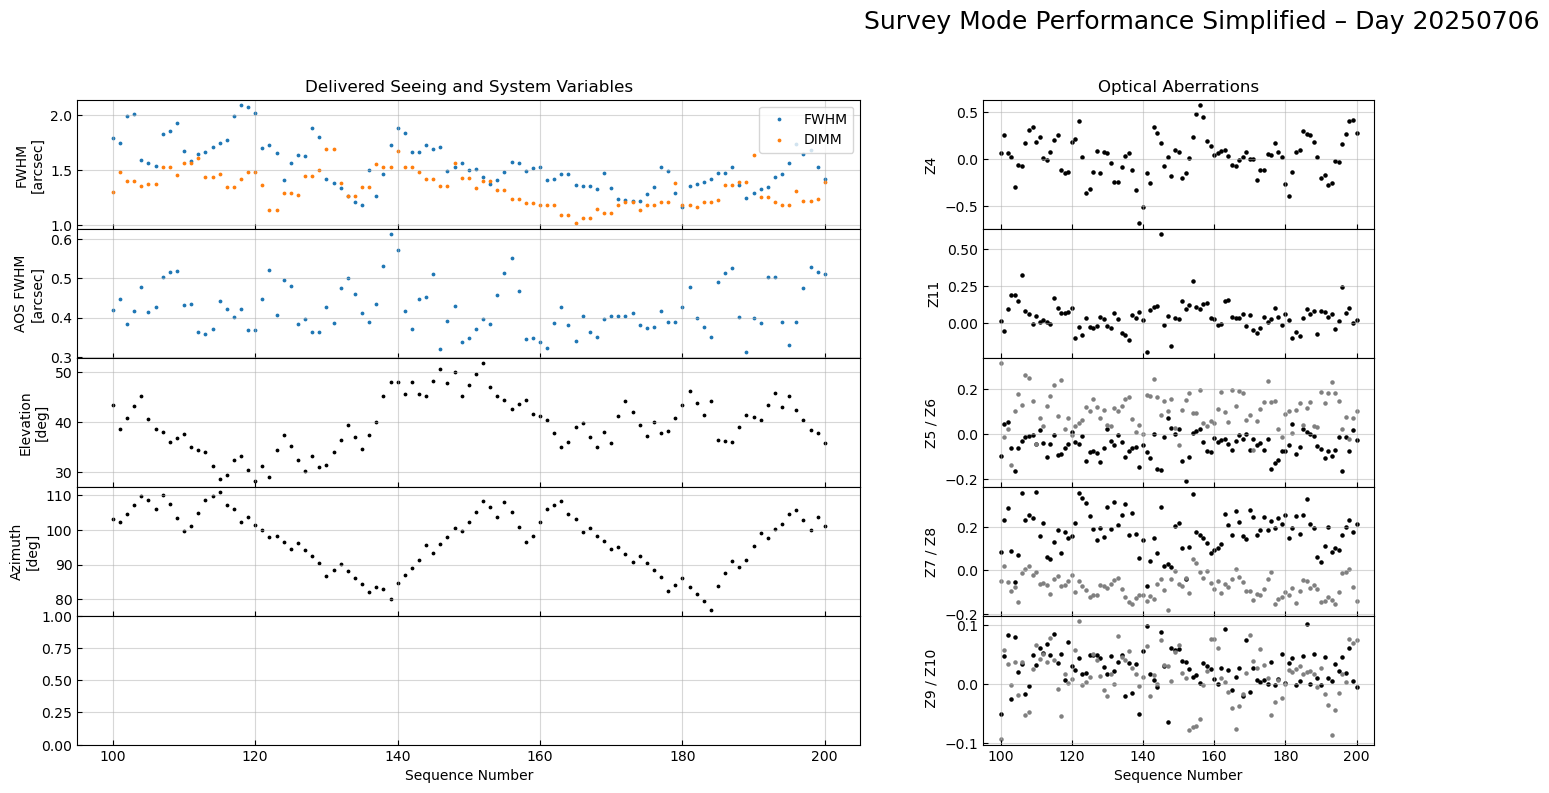

In [8]:
fig = plt.figure(figsize=(30, 15))


linewidth = 0.7
# Top 5x4 GridSpec occupies the upper half
gs_top = gridspec.GridSpec(
    nrows=5, ncols=4,
    width_ratios=[4, 2, 2, 2],
    height_ratios=[1]*5,
    hspace=0.0,
    wspace=0.25,
    top=0.97,
    bottom=0.54  # ends halfway down
)

# Bottom 5x4 GridSpec occupies the lower half
gs_bot = gridspec.GridSpec(
    nrows=5, ncols=4,
    width_ratios=[4, 2, 2, 2],
    height_ratios=[1]*5,
    hspace=0.0,
    top=0.46,
    bottom=0.05
)

# -- Left column: Survey performance
axes = []
for i in range(5):
    ax = fig.add_subplot(gs_top[i, 0], sharex=axes[0] if i > 0 else None)
    axes.append(ax)
axes[0].scatter(filtered_table['seq'], filtered_table['fwhm_zenith_500nm'], s=3, label='FWHM')
axes[0].scatter(filtered_table['seq'], filtered_table['dimm'], s=3, label='DIMM')
axes[0].legend()
axes[0].set_ylabel('FWHM [arcsec]')
axes[0].set_title(f'Delivered Seeing and System Variables')
axes[1].scatter(filtered_table['seq'], filtered_table["aos_fwhm"], s=3)
axes[2].scatter(filtered_table['seq'], filtered_table['elevation'], color='k', s=3)
axes[3].scatter(filtered_table['seq'], filtered_table['azimuth'], color='k', s=3)
# axes[4].scatter(filtered_table['seq'], filtered_table['rotation_angle'], color='k', s=3)

axes[0].set_ylabel('FWHM\n[arcsec]')
axes[1].set_ylabel('AOS FWHM\n[arcsec]')
axes[2].set_ylabel('Elevation\n[deg]')
axes[3].set_ylabel('Azimuth\n[deg]')
# axes[4].set_ylabel('Rotation\n[deg]')
axes[4].set_xlabel('Sequence Number')


for ax in axes[1::]:
    for x in jump_indices:
        ax.axvline(x=x, color='red', linestyle='--', linewidth=linewidth)
for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)
for ax in axes:
    ax.grid(True, alpha=0.5)
    ax.tick_params(direction='in', which='both')


# -- Right column: DoF plots with shared x-axis (not y)
axes = [fig.add_subplot(gs_top[i, 1]) for i in range(5)]
for id_group, (ax, zk_group) in enumerate(zip(axes, zk_groups)):
    for zk_idx, i in enumerate(zk_group):
        color = 'black' if zk_idx == 0 else 'gray' if zk_idx == 1 else None
        ax.scatter(seqs, zernikes_fwhm[:, i], s=5, color=color)
    ax.set_ylabel(zk_group_labels[id_group])
    ax.grid(True, alpha=0.5)
    ax.tick_params(direction="in")

for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)
    ax.grid(True, alpha=0.5)
for ax in axes:
    for x in jump_indices:
        ax.axvline(x=x, color='red', linestyle='--', linewidth=linewidth)
axes[-1].set_xlabel("Sequence Number")
axes[0].set_title(f'Optical Aberrations')


plt.tight_layout(rect=[0, 0, 1, 1])
fig.suptitle("Survey Mode Performance Simplified – Day " + str(day_obs), fontsize=18, y=1.03)

## Full Nightly Report

In [9]:
db = AOSDatabase(day_obs=day_obs, seq_min=seq_min, seq_max=seq_max)
await db.create(simplified=False)
table = db.table

/tmp/ipykernel_9241/72958265.py:187: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda row: np.array(row.fillna(0.0).values, dtype=float), axis=1
100%|██████████| 101/101 [06:13<00:00,  3.70s/it]


In [10]:
db.seq_max = 240
await db.update()
table = db.table

/tmp/ipykernel_9241/72958265.py:187: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda row: np.array(row.fillna(0.0).values, dtype=float), axis=1
100%|██████████| 40/40 [02:16<00:00,  3.42s/it]


In [11]:
filtered_table = table[table['day_obs'] == day_obs]
raw_filtered_table = table[table['day_obs'] == day_obs]
filtered_table = filtered_table.select_dtypes(include="number")
filtered_table = filtered_table.groupby("seq").mean().reset_index()

# -- AOS jumps
aos_diff = filtered_table["aos_fwhm"].diff()
jump_indices = filtered_table["seq"][aos_diff > 0.3].tolist()

# -- States array and labels
states_per_seq = (
    raw_filtered_table[["seq", "dof_state", "zernikes_fwhm", "lut_state"]]
    .drop_duplicates("seq")
    .dropna(subset=["dof_state", "zernikes_fwhm", "lut_state"])
    .set_index("seq")
)

dof_state = np.vstack(states_per_seq["dof_state"].values)
zernikes_fwhm = np.vstack(states_per_seq["zernikes_fwhm"].values)
lut_state = np.vstack(states_per_seq["lut_state"].values)
seqs = states_per_seq.index.values

<>:65: SyntaxWarning: invalid escape sequence '\D'
<>:65: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_9241/2093141525.py:65: SyntaxWarning: invalid escape sequence '\D'
  axes[0].set_ylabel(f'M1M3 $\Delta T$\n[C]')
/tmp/ipykernel_9241/2093141525.py:171: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(
/tmp/ipykernel_9241/2093141525.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 1])


Text(0.5, 1.03, 'Survey Mode Performance and AOS DoFs – Day 20250706')

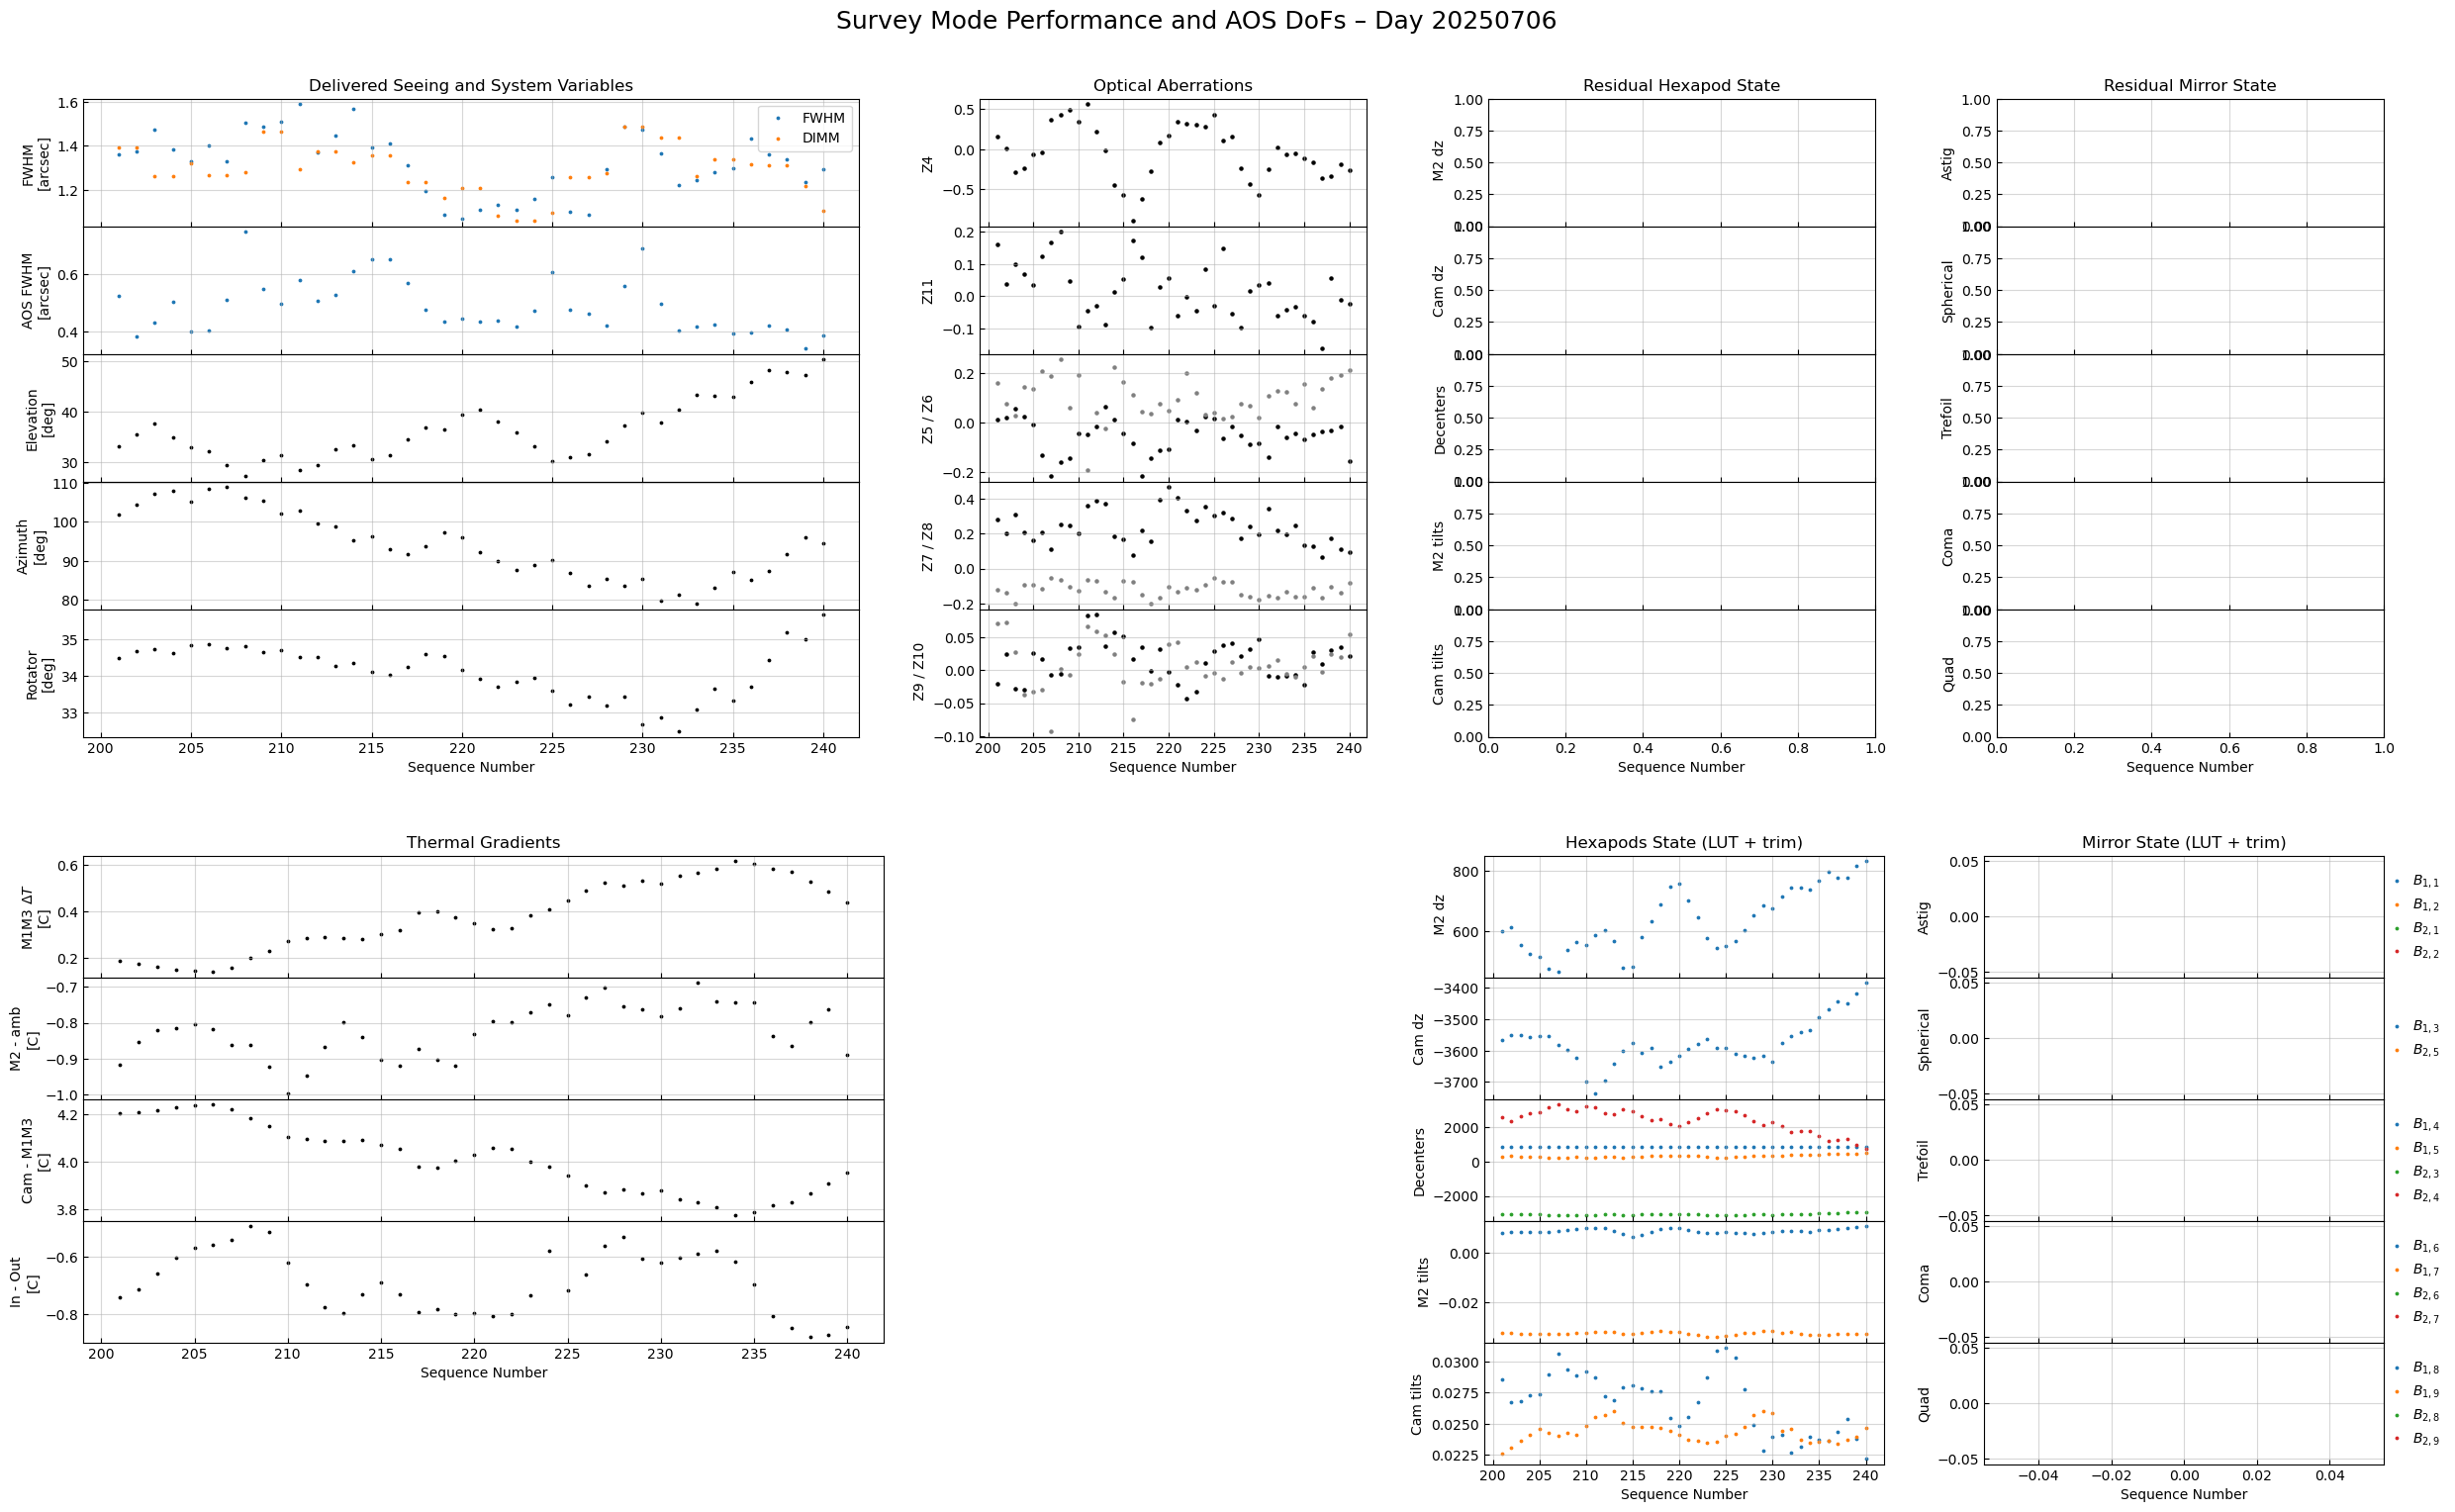

In [12]:
fig = plt.figure(figsize=(30, 15))


linewidth = 0.7
# Top 5x4 GridSpec occupies the upper half
gs_top = gridspec.GridSpec(
    nrows=5, ncols=4,
    width_ratios=[4, 2, 2, 2],
    height_ratios=[1]*5,
    hspace=0.0,
    wspace=0.25,
    top=0.97,
    bottom=0.54  # ends halfway down
)

# Bottom 5x4 GridSpec occupies the lower half
gs_bot = gridspec.GridSpec(
    nrows=5, ncols=4,
    width_ratios=[4, 2, 2, 2],
    height_ratios=[1]*5,
    hspace=0.0,
    top=0.46,
    bottom=0.05
)

# -- Left column: Survey performance
axes = []
for i in range(5):
    ax = fig.add_subplot(gs_top[i, 0], sharex=axes[0] if i > 0 else None)
    axes.append(ax)
axes[0].scatter(filtered_table['seq'], filtered_table['fwhm_zenith_500nm'], s=3, label='FWHM')
axes[0].scatter(filtered_table['seq'], filtered_table['dimm'], s=3, label='DIMM')
axes[0].legend()
axes[0].set_ylabel('FWHM [arcsec]')
axes[0].set_title(f'Delivered Seeing and System Variables')
axes[1].scatter(filtered_table['seq'], filtered_table["aos_fwhm"], s=3)
axes[2].scatter(filtered_table['seq'], filtered_table['elevation'], color='k', s=3)
axes[3].scatter(filtered_table['seq'], filtered_table['azimuth'], color='k', s=3)
axes[4].scatter(filtered_table['seq'], filtered_table['rotation_angle'], color='k', s=3)

axes[0].set_ylabel('FWHM\n[arcsec]')
axes[1].set_ylabel('AOS FWHM\n[arcsec]')
axes[2].set_ylabel('Elevation\n[deg]')
axes[3].set_ylabel('Azimuth\n[deg]')
axes[4].set_ylabel('Rotator\n[deg]')
axes[4].set_xlabel('Sequence Number')


for ax in axes[1::]:
    for x in jump_indices:
        ax.axvline(x=x, color='red', linestyle='--', linewidth=linewidth)
for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)
for ax in axes:
    ax.grid(True, alpha=0.5)
    ax.tick_params(direction='in', which='both')

# Thermal gradients 
axes = [fig.add_subplot(gs_bot[i, 0]) for i in range(4)]
axes[0].scatter(filtered_table['seq'], filtered_table['m1m3_delta_t'], color='k', s=3)
axes[1].scatter(filtered_table['seq'], filtered_table['m2_delta_t'], color='k', s=3)
axes[2].scatter(filtered_table['seq'], filtered_table['cam_hex_m1m3_delta_t'], color='k', s=3)
axes[3].scatter(filtered_table['seq'], filtered_table['dome_delta_t'], color='k', s=3)

axes[0].set_ylabel(f'M1M3 $\Delta T$\n[C]')
axes[1].set_ylabel('M2 - amb\n[C]')
axes[2].set_ylabel('Cam - M1M3\n[C]')
axes[3].set_ylabel('In - Out\n[C]')
axes[3].set_xlabel('Sequence Number')

for ax in axes:
    for x in jump_indices:
        ax.axvline(x=x, color='red', linestyle='--', linewidth=linewidth)
for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)
for ax in axes:
    ax.grid(True, alpha=0.5)
    ax.tick_params(direction='in', which='both')
axes[0].set_title(f'Thermal Gradients')

# -- Right column: DoF plots with shared x-axis (not y)
axes = [fig.add_subplot(gs_top[i, 1]) for i in range(5)]
for id_group, (ax, zk_group) in enumerate(zip(axes, zk_groups)):
    for zk_idx, i in enumerate(zk_group):
        color = 'black' if zk_idx == 0 else 'gray' if zk_idx == 1 else None
        ax.scatter(seqs, zernikes_fwhm[:, i], s=5, color=color)
    ax.set_ylabel(zk_group_labels[id_group])
    ax.grid(True, alpha=0.5)
    ax.tick_params(direction="in")

for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)
    ax.grid(True, alpha=0.5)
for ax in axes:
    for x in jump_indices:
        ax.axvline(x=x, color='red', linestyle='--', linewidth=linewidth)
axes[-1].set_xlabel("Sequence Number")
axes[0].set_title(f'Optical Aberrations')


# -- Right column: DoF plots with shared x-axis (not y)
axes = [fig.add_subplot(gs_bot[i, 2]) for i in range(5)]
for id_group, (ax, dof_group) in enumerate(zip(axes, groups)):
    for i in dof_group:
        ax.scatter(seqs, lut_state[:, i] + dof_state[:, i], label=f"{labels[i]}", s=3)
    ax.set_ylabel(group_labels[id_group])
    ax.grid(True, alpha=0.5)
    ax.tick_params(direction="in")

for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)
    ax.grid(True, alpha=0.5)
for ax in axes:
    for x in jump_indices:
        ax.axvline(x=x, color='red', linestyle='--', linewidth=linewidth)
axes[0].set_title(f'Hexapods State (LUT + trim)')
axes[-1].set_xlabel("Sequence Number")



# -- Right column: DoF plots with shared x-axis (not y)
axes = [fig.add_subplot(gs_bot[i, 3]) for i in range(5)]
for id_group, (ax, dof_group) in enumerate(zip(axes, mirror_groups)):
    for i in dof_group:
        #ax.scatter(seqs, dof_state[:, i], label=f"{all_labels[i]}", s=3)        
        ax.scatter(seqs, dof_state[:, i]+lut_state[:, i], label=f"{all_labels[i]}", s=3)
    ax.set_ylabel(mirror_group_labels[id_group])
    ax.grid(True, alpha=0.5)
    ax.tick_params(direction="in")
    ax.legend(
        loc='center left',
        bbox_to_anchor=(1.01, 0.5),
        borderaxespad=-0.75,
        frameon=False,
        fontsize=10,
        handletextpad=0.1
    )

for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)
    ax.grid(True, alpha=0.5)
for ax in axes:
    for x in jump_indices:
        ax.axvline(x=x, color='red', linestyle='--', linewidth=linewidth)
axes[-1].set_xlabel("Sequence Number")
axes[0].set_title(f'Mirror State (LUT + trim)')


# -- Right column: DoF plots with shared x-axis (not y)
axes = [fig.add_subplot(gs_top[i, 2]) for i in range(5)]
for id_group, (ax, dof_group) in enumerate(zip(axes, groups)):
    ax.set_ylabel(group_labels[id_group])
    ax.grid(True, alpha=0.5)
    ax.tick_params(direction="in")

for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)
    ax.grid(True, alpha=0.5)
for ax in axes:
    for x in jump_indices:
        ax.axvline(x=x, color='red', linestyle='--', linewidth=linewidth)
axes[0].set_title(f'Residual Hexapod State')
axes[-1].set_xlabel("Sequence Number")


axes = [fig.add_subplot(gs_top[i, 3]) for i in range(5)]
for id_group, (ax, dof_group) in enumerate(zip(axes, mirror_groups)):
    ax.set_ylabel(mirror_group_labels[id_group])
    ax.grid(True, alpha=0.5)
    ax.tick_params(direction="in")
    ax.legend(
        loc='center left',
        bbox_to_anchor=(1.01, 0.5),
        borderaxespad=-0.75,
        frameon=False,
        fontsize=10,
        handletextpad=0.1
    )

for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)
    ax.grid(True, alpha=0.5)
for ax in axes:
    for x in jump_indices:
        ax.axvline(x=x, color='red', linestyle='--', linewidth=linewidth)
axes[-1].set_xlabel("Sequence Number")
axes[0].set_title(f'Residual Mirror State')




plt.tight_layout(rect=[0, 0, 1, 1])
fig.suptitle("Survey Mode Performance and AOS DoFs – Day " + str(day_obs), fontsize=18, y=1.03)